In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
excel_data = pd.read_excel("Bird_Monitoring_Data_GRASSLAND.XLSX", sheet_name=None, engine='openpyxl')
print(excel_data.keys())

dict_keys(['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR'])


In [3]:
combined_df = pd.concat(excel_data.values(), ignore_index=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_17280\2028792663.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(excel_data.values(), ignore_index=True)


In [4]:
combined_df.head()

,Admin_Unit_Code,Sub_Unit_Code,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,...,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Previously_Obs,Initial_Three_Min_Cnt
0,ANTI,NaN,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,...,CHSP,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True
1,ANTI,NaN,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,...,EABL,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,False
2,ANTI,NaN,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,...,GRSP,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True
3,ANTI,NaN,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,...,EABL,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True
4,ANTI,NaN,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,...,FISP,False,True,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True


In [5]:
combined_df.shape

(8531, 29)

In [6]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8531 entries, 0 to 8530
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              8531 non-null   object        
 1   Sub_Unit_Code                0 non-null      object        
 2   Plot_Name                    8531 non-null   object        
 3   Location_Type                8531 non-null   object        
 4   Year                         8531 non-null   object        
 5   Date                         8531 non-null   datetime64[ns]
 6   Start_Time                   8531 non-null   object        
 7   End_Time                     8531 non-null   object        
 8   Observer                     8531 non-null   object        
 9   Visit                        8531 non-null   object        
 10  Interval_Length              8531 non-null   object        
 11  ID_Method                    8530 non-null 

In [7]:
combined_df.isna().sum()

Admin_Unit_Code                   0
Sub_Unit_Code                  8531
Plot_Name                         0
Location_Type                     0
Year                              0
Date                              0
Start_Time                        0
End_Time                          0
Observer                          0
Visit                             0
Interval_Length                   0
ID_Method                         1
Distance                       1394
Flyover_Observed                  0
Sex                               0
Common_Name                       0
Scientific_Name                   0
AcceptedTSN                      24
TaxonCode                         2
AOU_Code                          0
PIF_Watchlist_Status              0
Regional_Stewardship_Status       0
Temperature                       0
Humidity                          0
Sky                               0
Wind                              0
Disturbance                       0
Previously_Obs              

In [8]:
combined_df.drop(columns=['Sub_Unit_Code'], inplace=True)

In [9]:
mode_value = combined_df['Distance'].mode()[0]
combined_df['Distance'].fillna(mode_value, inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_17280\70422843.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['Distance'].fillna(mode_value, inplace=True)


In [10]:
missing_id_method_rows = combined_df[combined_df['ID_Method'].isna()]
missing_id_method_rows

,Admin_Unit_Code,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,...,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Previously_Obs,Initial_Three_Min_Cnt
1904,ANTI,ANTI-0140,Grassland,2018,2018-06-26,09:38:00,09:48:00,Kimberly Serno,2,7.5 - 10 min,...,AMCR,False,False,29.6,50.299999,Partly Cloudy,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,False


In [11]:
filter = combined_df[combined_df['AOU_Code'] == 'AMCR']
filter.head(20)

,Admin_Unit_Code,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,...,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Previously_Obs,Initial_Three_Min_Cnt
5,ANTI,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,0-2.5 min,...,AMCR,False,False,20.000000,79.000000,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True
115,ANTI,ANTI-0053,Grassland,2018,2018-05-23,05:40:00,05:50:00,Elizabeth Oswald,1,0-2.5 min,...,AMCR,False,False,21.000000,79.199997,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True
163,ANTI,ANTI-0017,Grassland,2018,2018-05-23,06:47:00,06:57:00,Elizabeth Oswald,1,5 - 7.5 min,...,AMCR,False,False,22.000000,77.500000,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,No effect on count,False,False
198,ANTI,ANTI-0008,Grassland,2018,2018-05-23,07:19:00,07:29:00,Elizabeth Oswald,1,7.5 - 10 min,...,AMCR,False,False,23.900000,74.199997,Partly Cloudy,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,False
301,ANTI,ANTI-0034,Grassland,2018,2018-05-23,08:48:00,08:58:00,Elizabeth Oswald,1,7.5 - 10 min,...,AMCR,False,False,26.500000,59.500000,Partly Cloudy,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,False
313,ANTI,ANTI-0043,Grassland,2018,2018-05-23,09:04:00,09:14:00,Elizabeth Oswald,1,5 - 7.5 min,...,AMCR,False,False,27.600000,59.900002,Partly Cloudy,"Gentle breeze (8-12 mph), leaves in motion",Slight effect on count,False,False
406,ANTI,ANTI-0116,Grassland,2018,2018-05-24,05:37:00,05:47:00,Kimberly Serno,1,0-2.5 min,...,AMCR,False,False,18.100000,68.099998,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,True
410,ANTI,ANTI-0091,Grassland,2018,2018-05-24,06:35:00,06:45:00,Kimberly Serno,1,2.5 - 5 min,...,AMCR,False,False,12.900000,83.300003,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,True
437,ANTI,ANTI-0108,Grassland,2018,2018-05-24,07:29:00,07:39:00,Kimberly Serno,1,0-2.5 min,...,AMCR,False,False,14.400000,89.599998,Clear or Few Clouds,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,True
453,ANTI,ANTI-0079,Grassland,2018,2018-05-24,06:51:00,07:01:00,Kimberly Serno,1,5 - 7.5 min,...,AMCR,False,False,12.900000,89.599998,Clear or Few Clouds,Light air movement (1-3 mph) smoke drifts,No effect on count,False,False


In [12]:
combined_df['ID_Method'].fillna('Singing', inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_17280\3865225957.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['ID_Method'].fillna('Singing', inplace=True)


In [13]:
combined_df['AcceptedTSN'].fillna('NULL', inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_17280\1537270811.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['AcceptedTSN'].fillna('NULL', inplace=True)
C:\Users\varsh\AppData\Local\Temp\ipykernel_17280\1537270811.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NULL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_df['AcceptedTSN'].fillna('NULL', inplace=True)


In [14]:
combined_df['TaxonCode'].fillna('NULL', inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_17280\3710384390.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['TaxonCode'].fillna('NULL', inplace=True)
C:\Users\varsh\AppData\Local\Temp\ipykernel_17280\3710384390.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NULL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_df['TaxonCode'].fillna('NULL', inplace=True)


In [15]:
combined_df['Sex'].fillna('Undetermined', inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_17280\307641280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['Sex'].fillna('Undetermined', inplace=True)


In [16]:
combined_df.isna().sum()

Admin_Unit_Code                0
Plot_Name                      0
Location_Type                  0
Year                           0
Date                           0
Start_Time                     0
End_Time                       0
Observer                       0
Visit                          0
Interval_Length                0
ID_Method                      0
Distance                       0
Flyover_Observed               0
Sex                            0
Common_Name                    0
Scientific_Name                0
AcceptedTSN                    0
TaxonCode                      0
AOU_Code                       0
PIF_Watchlist_Status           0
Regional_Stewardship_Status    0
Temperature                    0
Humidity                       0
Sky                            0
Wind                           0
Disturbance                    0
Previously_Obs                 0
Initial_Three_Min_Cnt          0
dtype: int64

In [17]:
combined_df.head(5)

,Admin_Unit_Code,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,Interval_Length,...,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Previously_Obs,Initial_Three_Min_Cnt
0,ANTI,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,0-2.5 min,...,CHSP,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True
1,ANTI,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,7.5 - 10 min,...,EABL,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,False
2,ANTI,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,0-2.5 min,...,GRSP,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True
3,ANTI,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,0-2.5 min,...,EABL,False,False,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True
4,ANTI,ANTI-0054,Grassland,2018,2018-05-22,05:35:00,05:45:00,Elizabeth Oswald,1,0-2.5 min,...,FISP,False,True,20.0,79.0,Cloudy/Overcast,Light breeze (4-7 mph) wind felt on face,Slight effect on count,False,True


In [18]:
combined_df.to_csv('grasslandbirds.csv', index=False)

UNIVARIATE ANALYSIS

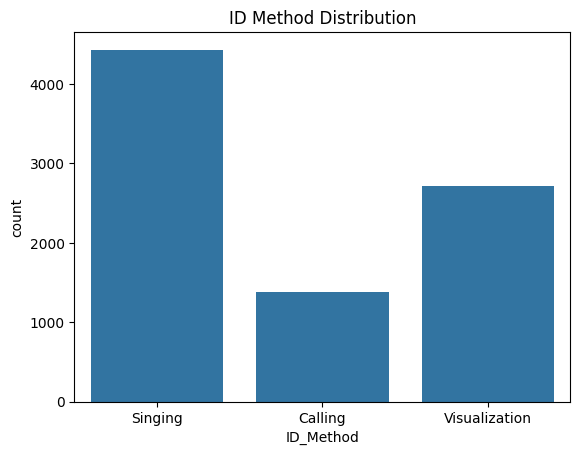

In [19]:
sns.countplot(x='ID_Method', data=combined_df)
plt.title('ID Method Distribution')
plt.show()

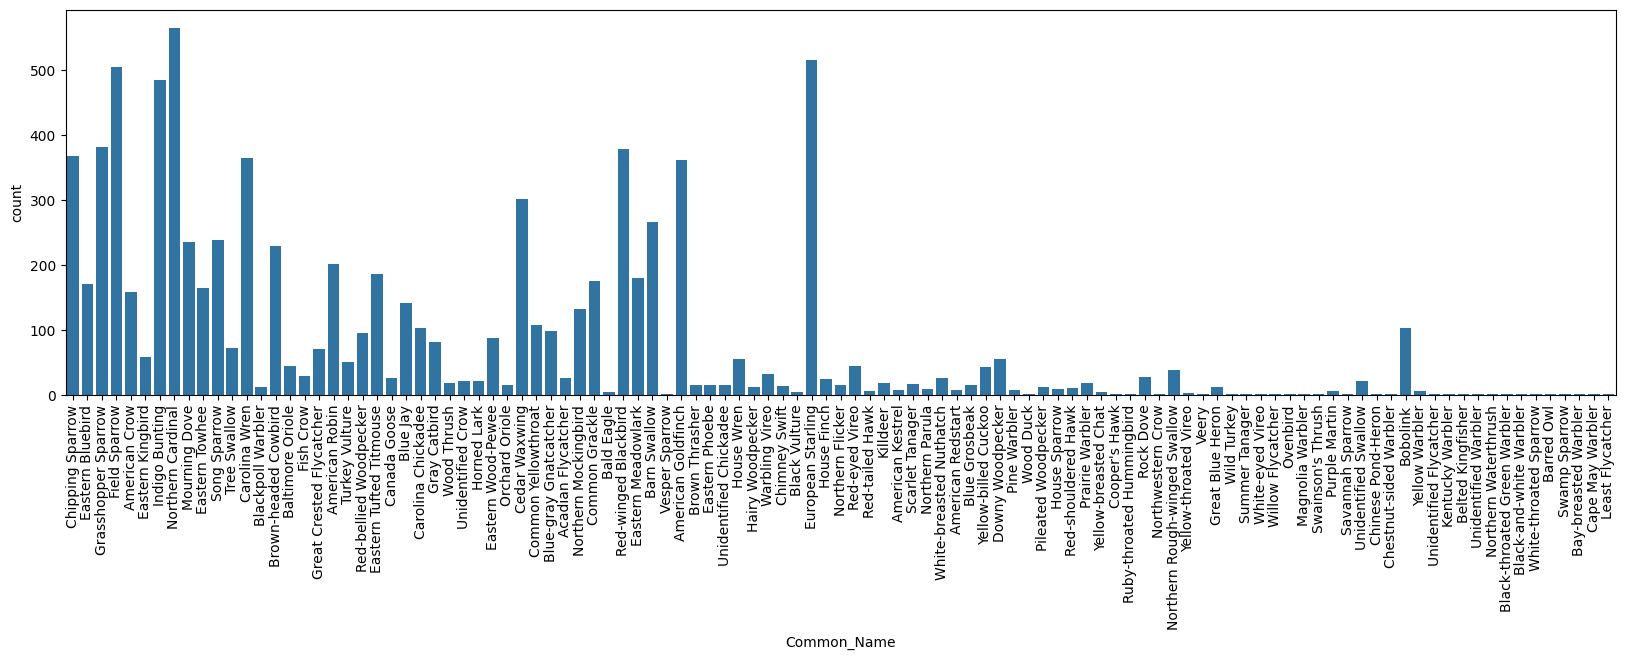

In [20]:
plt.figure(figsize=(20, 5))
sns.countplot(x='Common_Name', data=combined_df)
plt.xticks(rotation=90)
plt.show()

In [21]:
combined_df['Common_Name'].nunique()

107

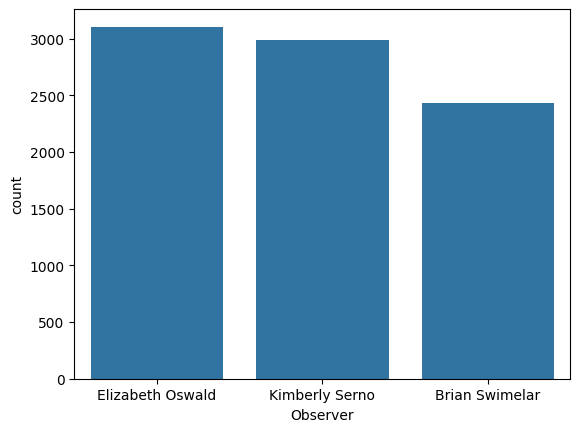

In [22]:
sns.countplot(x='Observer', data=combined_df)
plt.show()

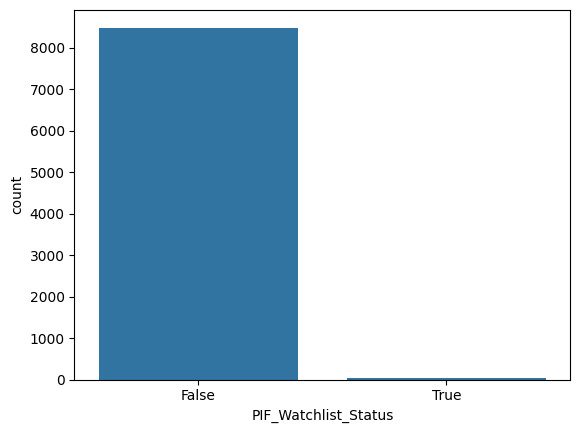

In [23]:
sns.countplot(x='PIF_Watchlist_Status', data=combined_df)
plt.show()

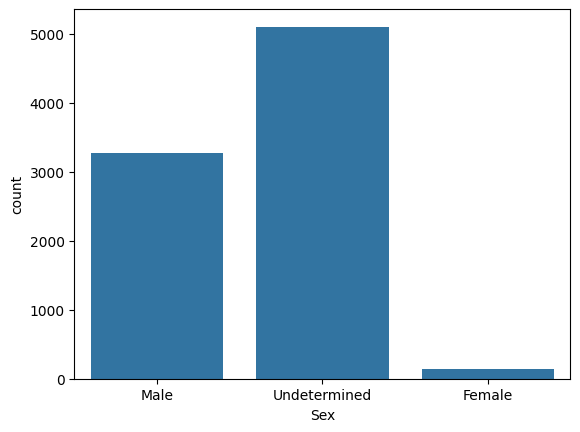

In [24]:
sns.countplot(x='Sex', data=combined_df)
plt.show()

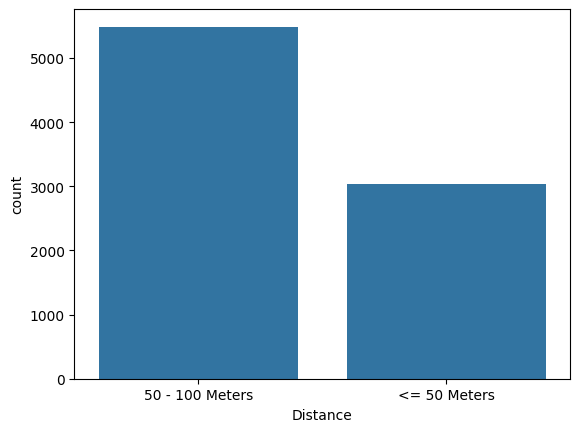

In [25]:
sns.countplot(x='Distance', data=combined_df)
plt.show()

BIVARIATE ANALYSIS

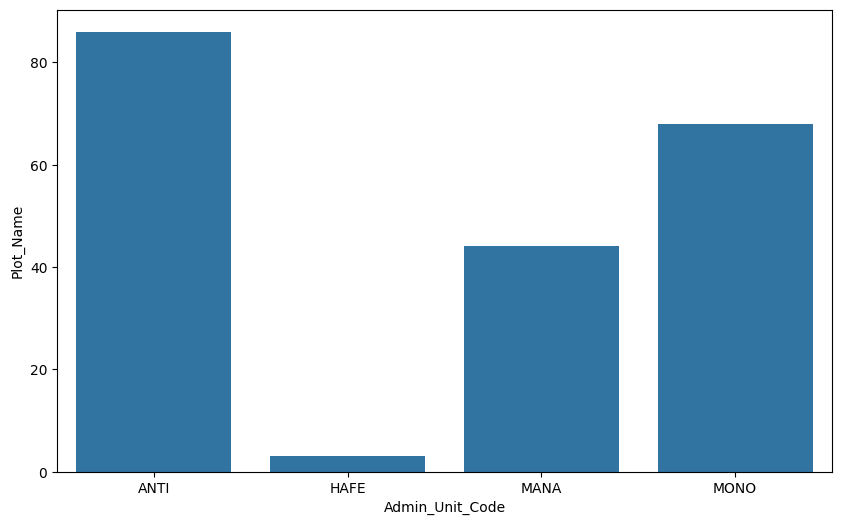

In [26]:
unique_sites = combined_df.groupby('Admin_Unit_Code')['Plot_Name'].nunique().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=unique_sites, x='Admin_Unit_Code', y='Plot_Name')
plt.show()

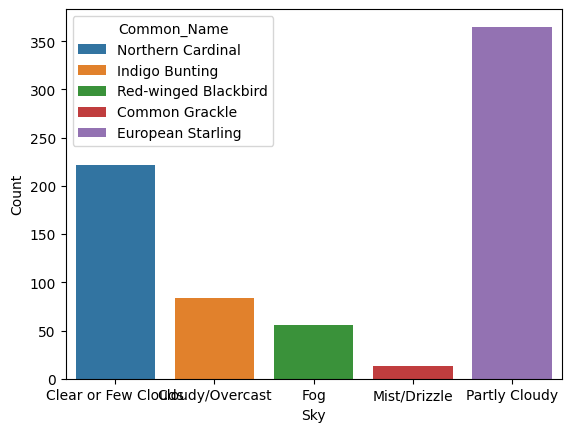

In [27]:
bird_count_by_sky = combined_df.groupby(['Sky', 'Common_Name']).size().reset_index(name='Count')
bird_count_by_sky_max = bird_count_by_sky.loc[bird_count_by_sky.groupby('Sky')['Count'].idxmax()]
sns.barplot(data=bird_count_by_sky_max, x='Sky', y='Count', hue='Common_Name')
plt.show()

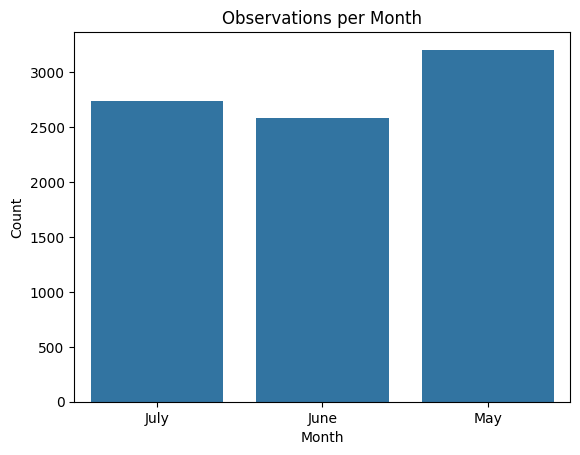

In [28]:
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df['Month'] = combined_df['Date'].dt.month_name()
monthly = combined_df.groupby('Month').size().reset_index(name='Count')
sns.barplot(data=monthly, x='Month', y='Count')
plt.title('Observations per Month')
plt.show()

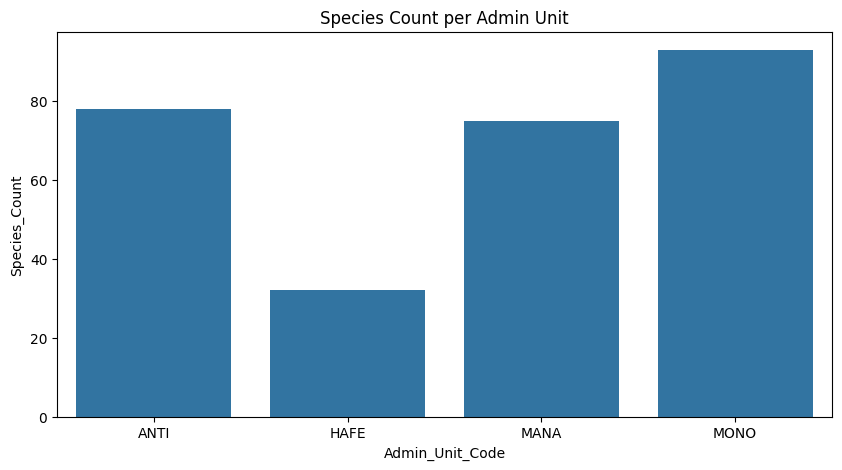

In [29]:
species_by_admin = combined_df.groupby('Admin_Unit_Code')['Common_Name'].nunique().reset_index(name='Species_Count')
plt.figure(figsize=(10, 5))
sns.barplot(data=species_by_admin, x='Admin_Unit_Code', y='Species_Count')
plt.title('Species Count per Admin Unit')
plt.show()

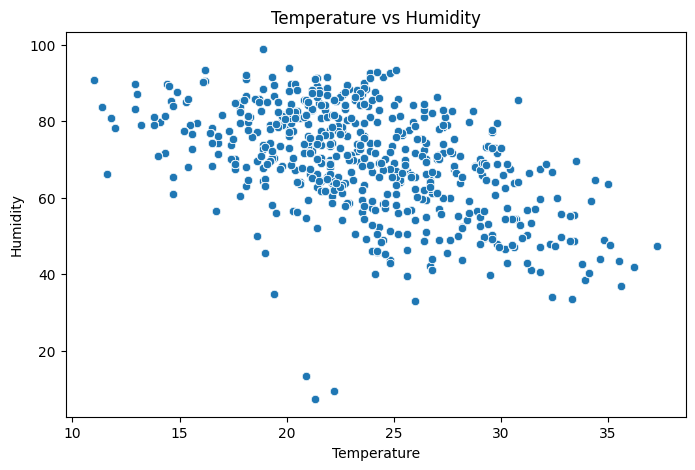

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=combined_df, x='Temperature', y='Humidity')
plt.title('Temperature vs Humidity')
plt.show()